# Etapa 2 - Análise Exploratória de Dados (EDA)

## Objetivo
Entender o comportamento dos dados, identificar padrões e correlações que guiam a preparação e modelagem.

## O que vamos fazer?
1. Carregar dados já validados
2. Explorar estatísticas descritivas
3. Analisar comportamento do Churn
4. Criar visualizações
5. Documentar insights

In [2]:
!pip install matplotlib seaborn

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----------------------------------- ---- 71.7/80.3 kB 2.0 MB/s eta 0:00:01
     ---------------------------------------- 80.3/80.3 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ------------------- ------------------- 61.4/121.0 kB 1.6 MB/s eta 0:00:01
     ----------------------------------- -- 112.6/121.0 kB 1.3 MB/s eta 0:00:01
     ------------------------------------ 121.0/121.0 kB 886.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    --------------------------------------- 0.2/9.3 MB 4.5 MB/s eta 0:00:03
   - -------------------------------------- 0.3/9.3 MB 3.9 MB/s eta 0:00:03
   - -------------------------------------- 0.4/9.3 MB 3.1 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/9.3 MB 3.4 MB/s eta 0:00:03
   --- ------------------------------------ 0.7/9.3 MB 3.1 MB/s eta 0:00:03
   ---


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\Kawan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✓ Bibliotecas importadas com sucesso!")

Matplotlib is building the font cache; this may take a moment.


✓ Bibliotecas importadas com sucesso!


In [4]:
# CARREGAR DADOS VALIDADOS DA ETAPA 1
# Usar o mesmo sistema de caminhos da etapa anterior

try:
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        project_root = notebook_dir.parent
    else:
        project_root = notebook_dir
    
    print(f"Diretório do projeto: {project_root}")
except:
    project_root = Path.cwd()

# Caminhos
data_processed_dir = project_root / "data" / "processed"
artifacts_plots_dir = project_root / "artifacts" / "plots"
artifacts_plots_dir.mkdir(parents=True, exist_ok=True)

# Carregar dados
input_file = data_processed_dir / "01_raw_validated.csv"
df = pd.read_csv(input_file)

print(f"\n{'='*60}")
print("DADOS CARREGADOS")
print(f"{'='*60}")
print(f"Dimensões: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"\nPrimeiras 5 linhas:")
print(df.head())

Diretório do projeto: c:\Temp\telco-churn-ml

DADOS CARREGADOS
Dimensões: 7043 linhas, 21 colunas

Primeiras 5 linhas:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No 

In [5]:
print("\n" + "="*60)
print("1. ESTATÍSTICAS DESCRITIVAS")
print("="*60)

print("\nResumo estatístico (numéricas):")
print(df.describe().round(2))

print("\nTipos de dados:")
print(df.dtypes)


1. ESTATÍSTICAS DESCRITIVAS

Resumo estatístico (numéricas):
       SeniorCitizen   tenure  MonthlyCharges
count        7043.00  7043.00         7043.00
mean            0.16    32.37           64.76
std             0.37    24.56           30.09
min             0.00     0.00           18.25
25%             0.00     9.00           35.50
50%             0.00    29.00           70.35
75%             0.00    55.00           89.85
max             1.00    72.00          118.75

Tipos de dados:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Mon

In [6]:
print("\n" + "="*60)
print("2. EXPLORAÇÃO DA VARIÁVEL ALVO (CHURN)")
print("="*60)

if 'Churn' in df.columns:
    churn_value_counts = df['Churn'].value_counts()
    churn_pct = df['Churn'].value_counts(normalize=True) * 100
    
    print("\nDistribuição de Churn:")
    for category in churn_value_counts.index:
        print(f"  {category}: {churn_value_counts[category]} ({churn_pct[category]:.2f}%)")
    
    print("\n⚠️ Dados desbalanceados - isso vai afetar a escolha de métrica!")
else:
    print("❌ Coluna 'Churn' não encontrada!")


2. EXPLORAÇÃO DA VARIÁVEL ALVO (CHURN)

Distribuição de Churn:
  No: 5174 (73.46%)
  Yes: 1869 (26.54%)

⚠️ Dados desbalanceados - isso vai afetar a escolha de métrica!


In [7]:
print("\n" + "="*60)
print("3. CORRELAÇÃO COM CHURN (variáveis numéricas)")
print("="*60)

# Converter Churn para numérico para correlação
df_numeric = df.copy()
if df_numeric['Churn'].dtype == 'object':
    df_numeric['Churn'] = (df_numeric['Churn'] == 'Yes').astype(int)

# Selecionar apenas colunas numéricas
numeric_cols = df_numeric.select_dtypes(include=[np.number]).columns
correlation_with_churn = df_numeric[numeric_cols].corr()['Churn'].sort_values(ascending=False)

print("\nCorrelação com Churn (mais forte para mais fraca):")
print(correlation_with_churn)


3. CORRELAÇÃO COM CHURN (variáveis numéricas)

Correlação com Churn (mais forte para mais fraca):
Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn, dtype: float64



4. MATRIZ DE CORRELAÇÃO (heatmap)

✓ Gráfico salvo em: c:\Temp\telco-churn-ml\artifacts\plots\01_correlation_heatmap.png


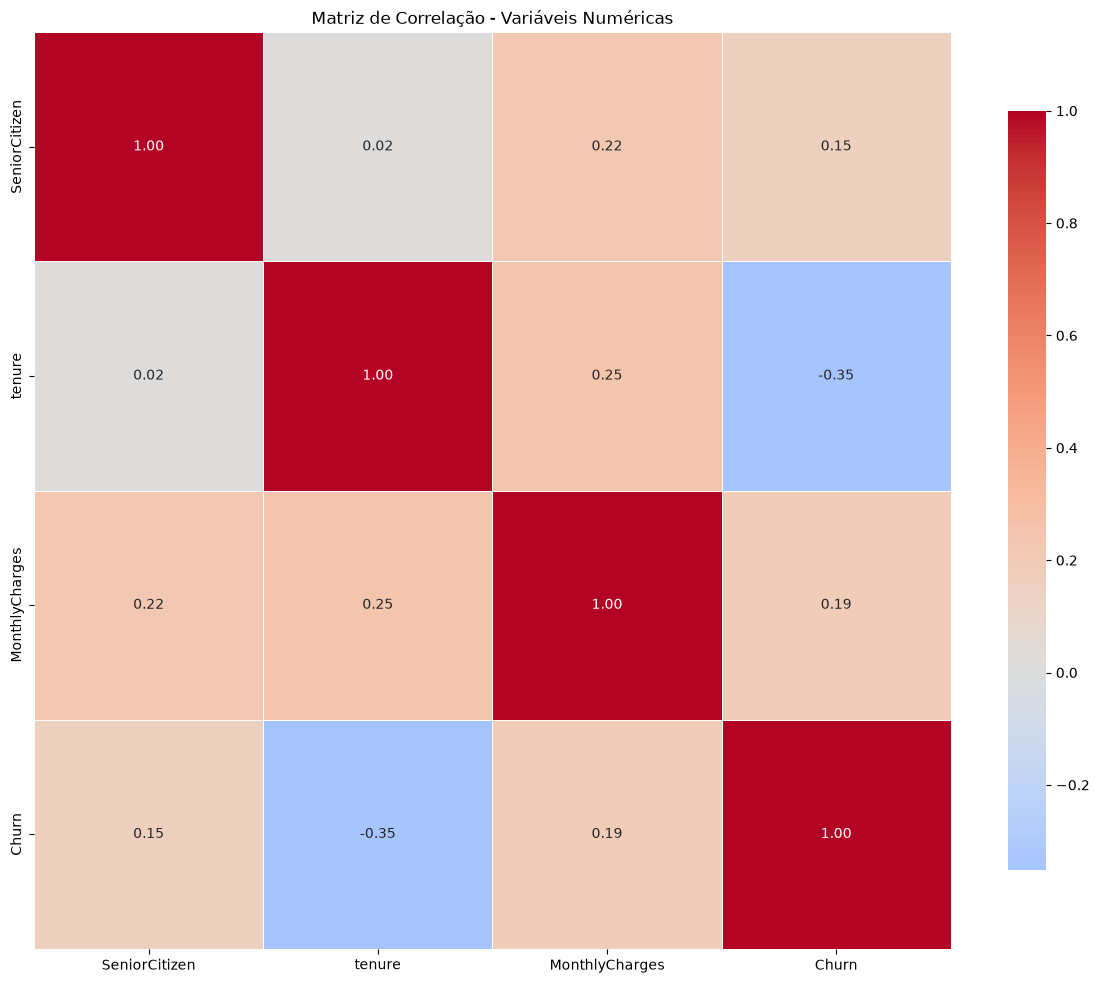

In [8]:
print("\n" + "="*60)
print("4. MATRIZ DE CORRELAÇÃO (heatmap)")
print("="*60)

# Criar figura
plt.figure(figsize=(12, 10))

# Selecionar colunas numéricas
numeric_df = df_numeric[numeric_cols]
correlation_matrix = numeric_df.corr()

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.tight_layout()

# Salvar
output_path = artifacts_plots_dir / "01_correlation_heatmap.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfico salvo em: {output_path}")
plt.show()


5. ANÁLISE UNIVARIADA - VARIÁVEIS NUMÉRICAS

✓ Gráfico salvo em: c:\Temp\telco-churn-ml\artifacts\plots\02_numeric_distributions.png


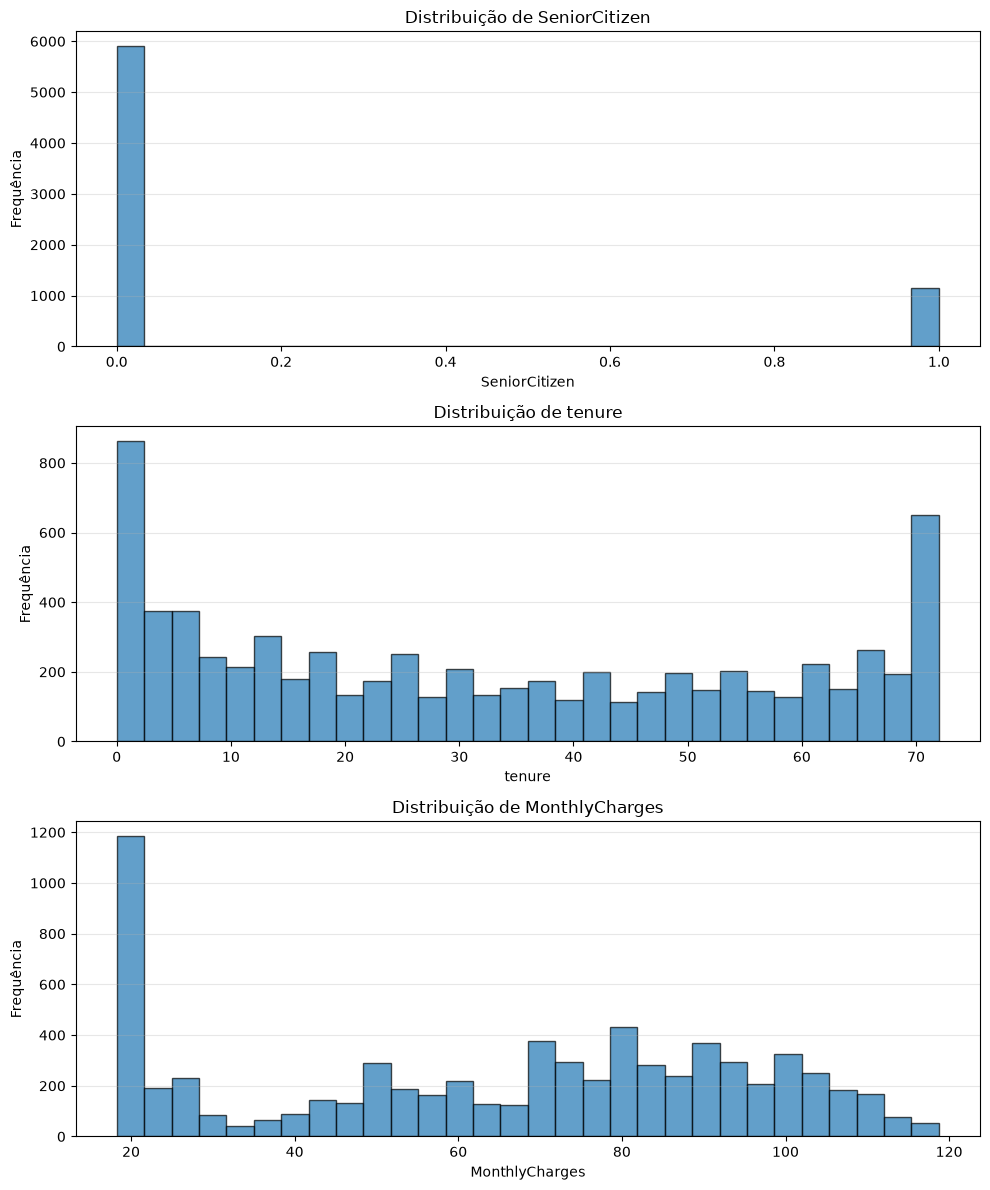

In [9]:
print("\n" + "="*60)
print("5. ANÁLISE UNIVARIADA - VARIÁVEIS NUMÉRICAS")
print("="*60)

# Selecionar colunas numéricas principais
numeric_features = [col for col in numeric_cols if col != 'Churn']

# Criar subplots
n_cols = len(numeric_features)
fig, axes = plt.subplots(n_cols, 1, figsize=(10, 4*n_cols))

if n_cols == 1:
    axes = [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"Distribuição de {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequência")
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Salvar
output_path = artifacts_plots_dir / "02_numeric_distributions.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfico salvo em: {output_path}")
plt.show()


6. CHURN POR VARIÁVEIS CATEGÓRICAS

Variáveis categóricas encontradas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Variáveis selecionadas para análise:
['gender', 'Partner', 'Dependents', 'PhoneService']

✓ Gráfico salvo em: c:\Temp\telco-churn-ml\artifacts\plots\03_categorical_churn.png


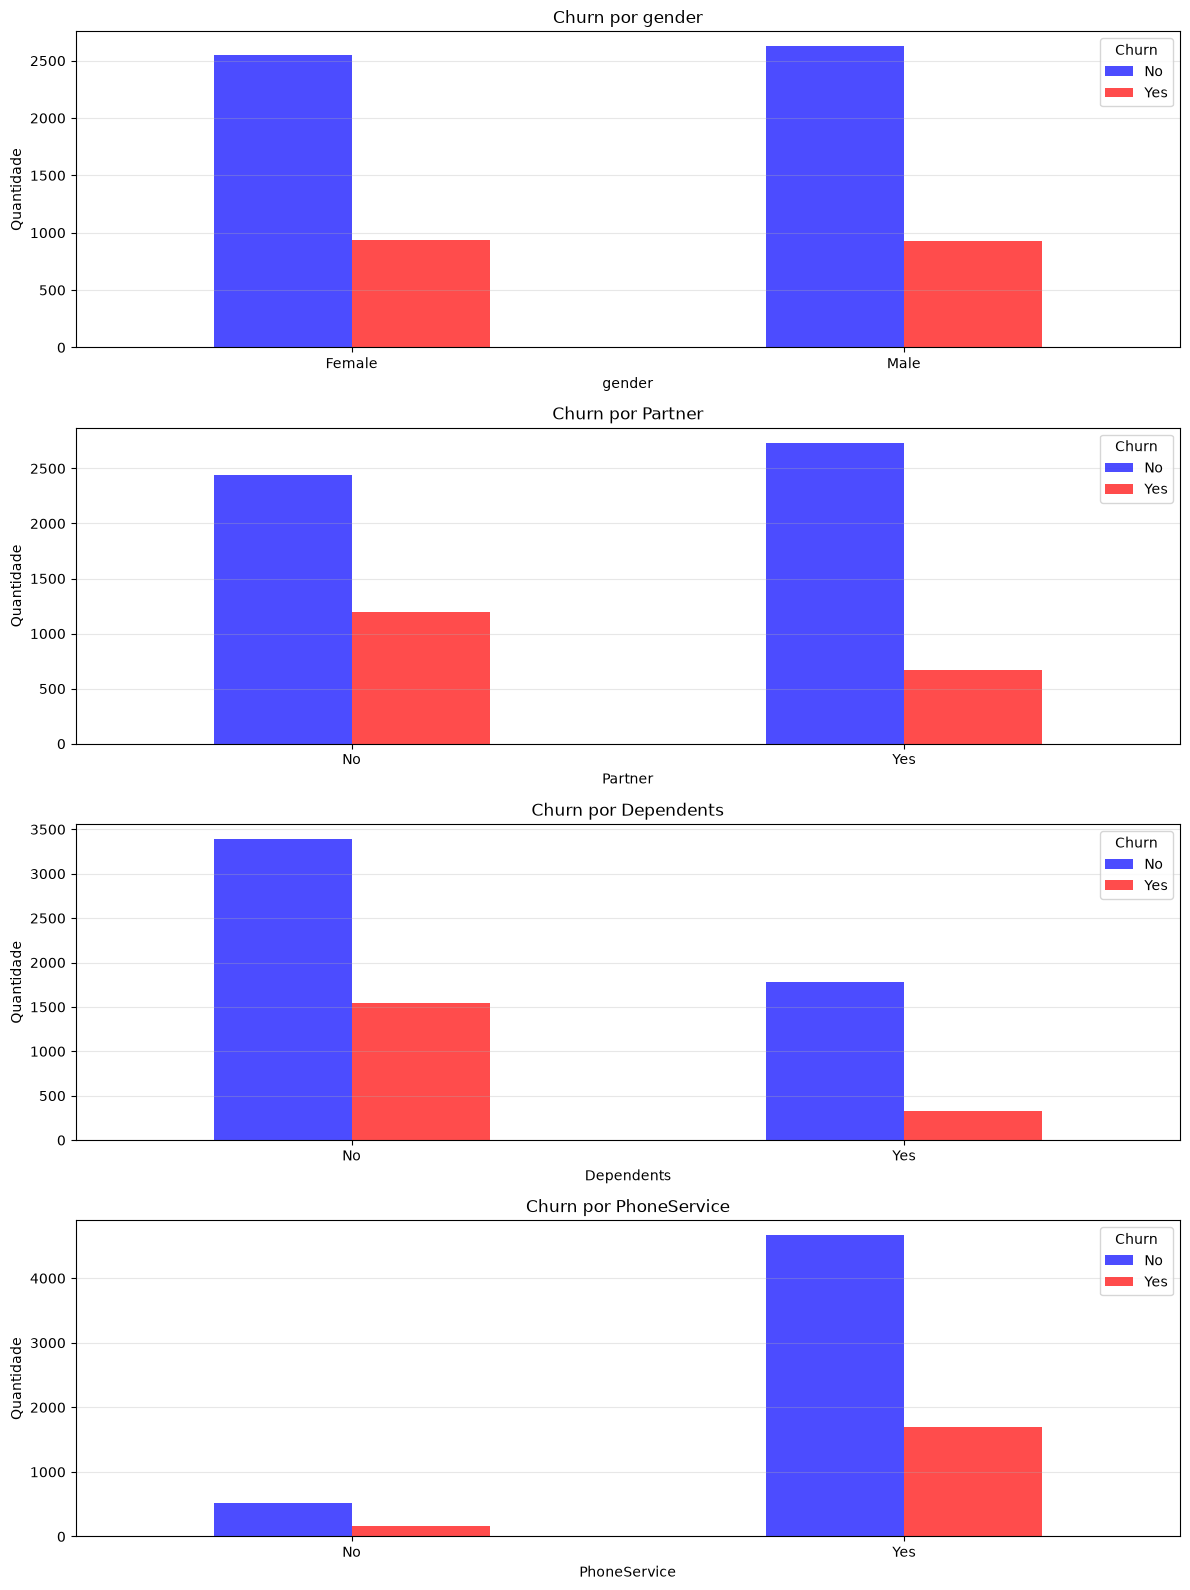

In [16]:
print("\n" + "="*60)
print("6. CHURN POR VARIÁVEIS CATEGÓRICAS")
print("="*60)

# ============================================================
# 1. Selecionar variáveis categóricas
# ============================================================

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remover variável alvo e identificador
categorical_cols = [
    col for col in categorical_cols
    if col not in ['Churn', 'customerID']
]

print(f"\nVariáveis categóricas encontradas:")
print(categorical_cols)


# ============================================================
# 2. Selecionar principais variáveis para visualização
# ============================================================

main_categorical = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService'
]

print(f"\nVariáveis selecionadas para análise:")
print(main_categorical)


# ============================================================
# 3. Criar gráficos
# ============================================================

fig, axes = plt.subplots(
    len(main_categorical),
    1,
    figsize=(12, 4 * len(main_categorical))
)

# Caso exista apenas uma variável
if len(main_categorical) == 1:
    axes = [axes]


for idx, col in enumerate(main_categorical):

    # --------------------------------------------------------
    # Contagem de Churn por categoria
    # --------------------------------------------------------

    churn_by_category = pd.crosstab(
        df[col],
        df['Churn']
    )

    # Garantir que as colunas No e Yes existam
    for churn_value in ['No', 'Yes']:
        if churn_value not in churn_by_category.columns:
            churn_by_category[churn_value] = 0

    churn_by_category = churn_by_category[['No', 'Yes']]

    # --------------------------------------------------------
    # Gráfico
    # --------------------------------------------------------

    churn_by_category.plot(
        kind='bar',
        ax=axes[idx],
        color=['blue', 'red'],
        alpha=0.7
    )

    axes[idx].set_title(f"Churn por {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Quantidade")
    axes[idx].legend(title='Churn')
    axes[idx].grid(
        axis='y',
        alpha=0.3
    )

    # Rotacionar labels
    axes[idx].tick_params(
        axis='x',
        rotation=0
    )


plt.tight_layout()


# ============================================================
# 4. Salvar gráfico
# ============================================================

output_path = artifacts_plots_dir / "03_categorical_churn.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

print(f"\n✓ Gráfico salvo em: {output_path}")

plt.show()


6.1 TAXA DE CHURN POR VARIÁVEIS CATEGÓRICAS

✓ Gráfico salvo em: c:\Temp\telco-churn-ml\artifacts\plots\04_categorical_churn_rate.png


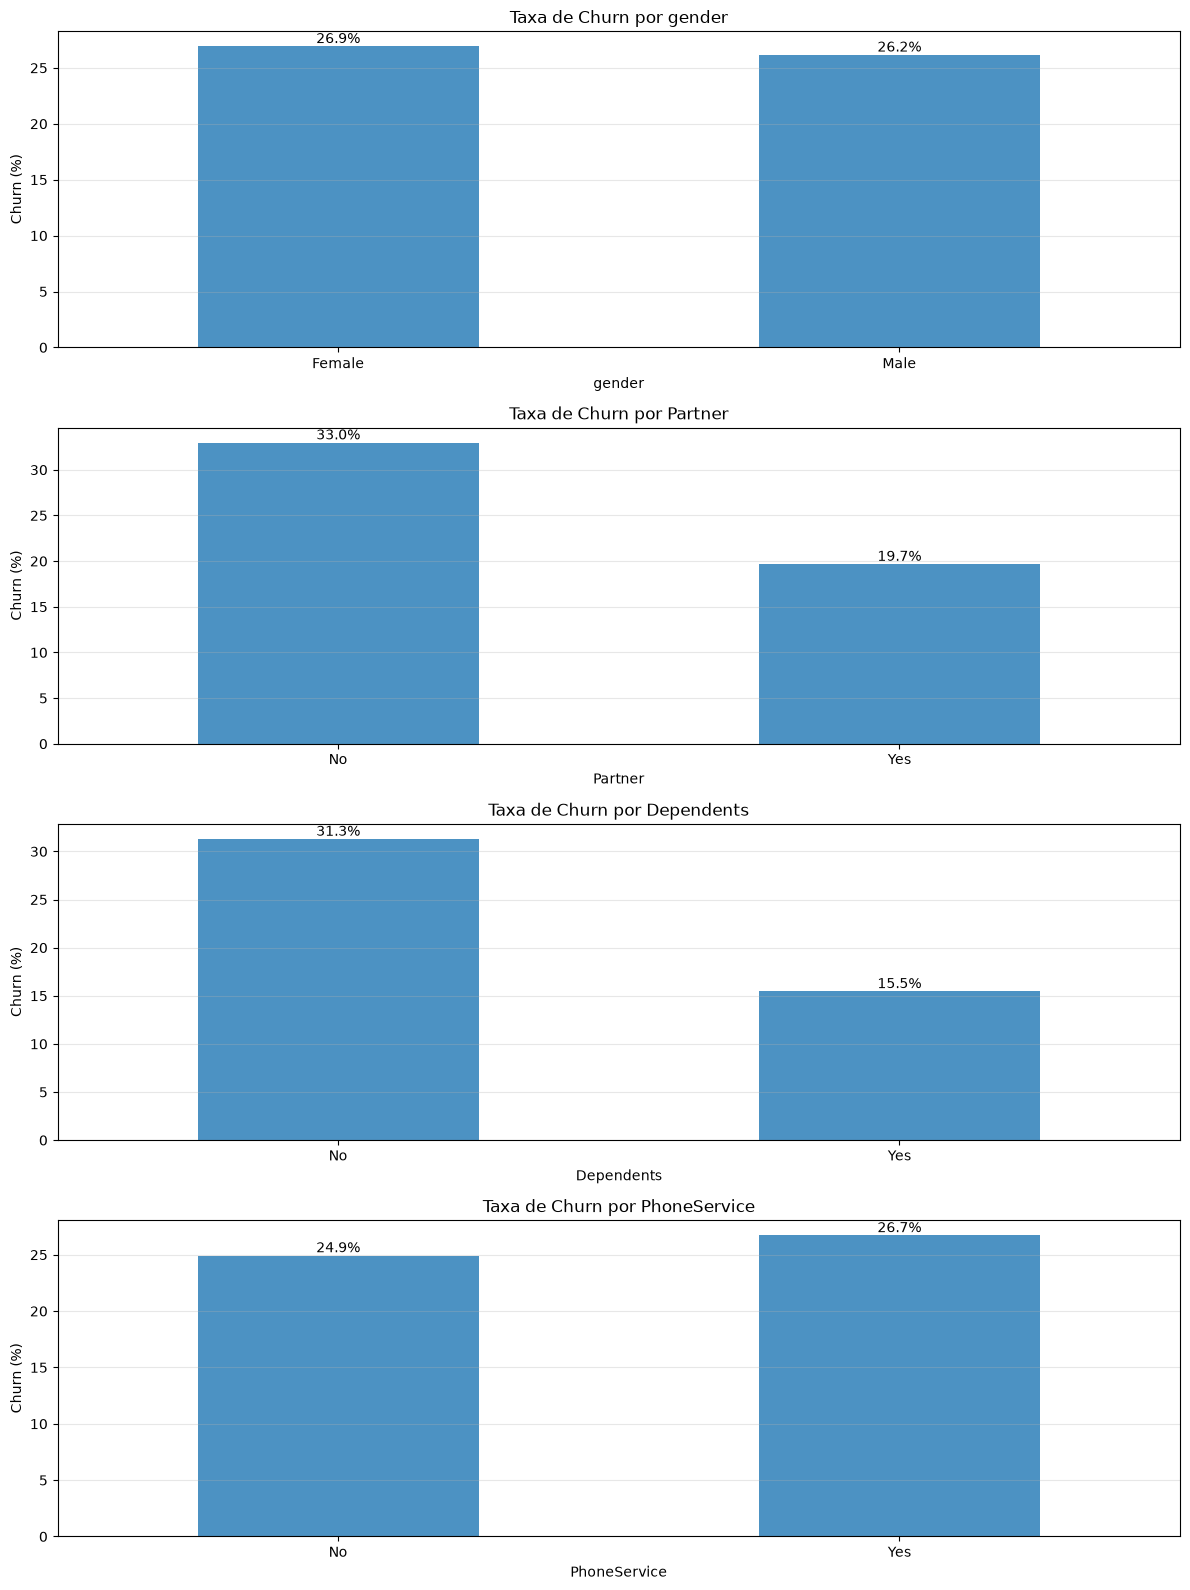

In [17]:
print("\n" + "="*60)
print("6.1 TAXA DE CHURN POR VARIÁVEIS CATEGÓRICAS")
print("="*60)

fig, axes = plt.subplots(
    len(main_categorical),
    1,
    figsize=(12, 4 * len(main_categorical))
)

if len(main_categorical) == 1:
    axes = [axes]


for idx, col in enumerate(main_categorical):

    # Calcular percentual de churn
    churn_rate = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
    )

    # Gráfico
    churn_rate.plot(
        kind='bar',
        ax=axes[idx],
        alpha=0.8
    )

    axes[idx].set_title(
        f"Taxa de Churn por {col}"
    )

    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Churn (%)")

    axes[idx].grid(
        axis='y',
        alpha=0.3
    )

    axes[idx].tick_params(
        axis='x',
        rotation=0
    )

    # Adicionar valores nas barras
    for container in axes[idx].containers:
        axes[idx].bar_label(
            container,
            fmt='%.1f%%'
        )


plt.tight_layout()

output_path = (
    artifacts_plots_dir /
    "04_categorical_churn_rate.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

print(f"\n✓ Gráfico salvo em: {output_path}")

plt.show()


8. RELAÇÃO TENURE x CHURN

✓ Gráfico salvo em: c:\Temp\telco-churn-ml\artifacts\plots\04_tenure_analysis.png


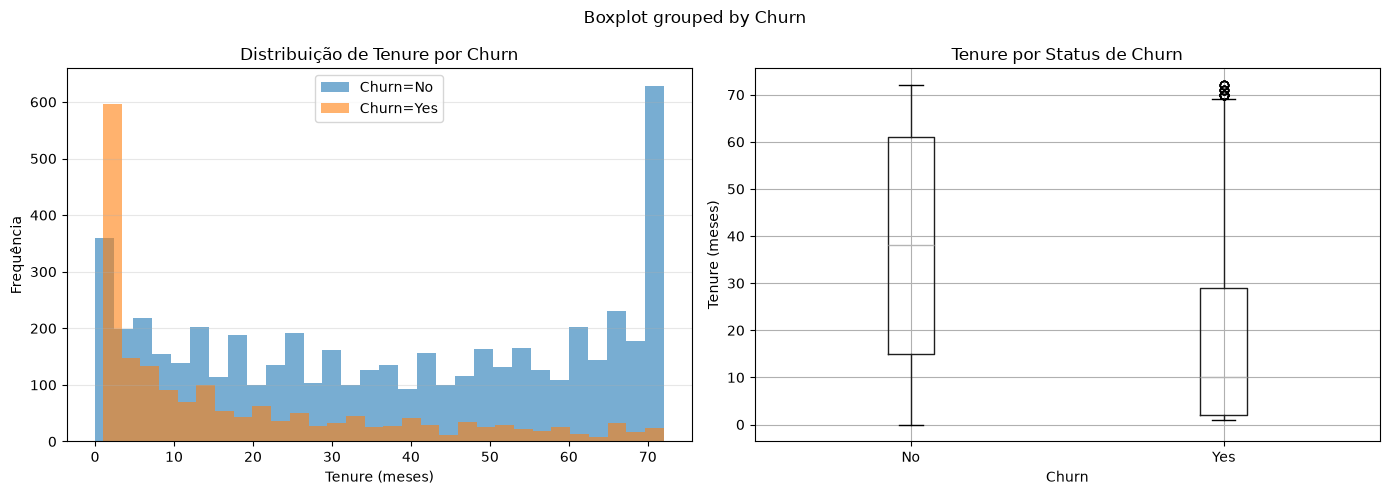

In [12]:
print("\n" + "="*60)
print("8. RELAÇÃO TENURE x CHURN")
print("="*60)

# Visualizar tenure vs churn
if 'tenure' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma de tenure por churn
    for churn_val in df['Churn'].unique():
        axes[0].hist(df[df['Churn'] == churn_val]['tenure'], bins=30, alpha=0.6, label=f'Churn={churn_val}')
    axes[0].set_title("Distribuição de Tenure por Churn")
    axes[0].set_xlabel("Tenure (meses)")
    axes[0].set_ylabel("Frequência")
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Box plot
    df.boxplot(column='tenure', by='Churn', ax=axes[1])
    axes[1].set_title("Tenure por Status de Churn")
    axes[1].set_xlabel("Churn")
    axes[1].set_ylabel("Tenure (meses)")
    
    plt.tight_layout()
    
    # Salvar
    output_path = artifacts_plots_dir / "04_tenure_analysis.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Gráfico salvo em: {output_path}")
    plt.show()
else:
    print("⚠️ Coluna 'tenure' não encontrada")

In [13]:
print("\n" + "="*60)
print("9. INSIGHTS PRINCIPAIS")
print("="*60)

print("\nResumo dos achados:")
print(f"1. Taxa total de churn: {(df['Churn'] == 'Yes').sum() / len(df) * 100:.2f}%")
print(f"2. Clientes com churn: {(df['Churn'] == 'Yes').sum()}")
print(f"3. Clientes sem churn: {(df['Churn'] == 'No').sum()}")




9. INSIGHTS PRINCIPAIS

Resumo dos achados:
1. Taxa total de churn: 26.54%
2. Clientes com churn: 1869
3. Clientes sem churn: 5174


In [14]:
print("\n" + "="*60)
print("10. SALVANDO RESUMO DA EDA")
print("="*60)

# Criar resumo em arquivo
summary_path = project_root / "reports" / "EDA_Summary.txt"
summary_path.parent.mkdir(parents=True, exist_ok=True)

summary_text = f"""
EDA SUMMARY - TELCO CUSTOMER CHURN
{'='*60}

Dataset Dimensions:
  - Linhas: {df.shape[0]}
  - Colunas: {df.shape[1]}

Churn Distribution:
  - Clientes com churn (Yes): {(df['Churn'] == 'Yes').sum()} ({(df['Churn'] == 'Yes').sum() / len(df) * 100:.2f}%)
  - Clientes sem churn (No): {(df['Churn'] == 'No').sum()} ({(df['Churn'] == 'No').sum() / len(df) * 100:.2f}%)

Top Correlations with Churn:
{correlation_with_churn.head(10).to_string()}

Gráficos Gerados:
  1. Matriz de Correlação
  2. Distribuições Numéricas
  3. Churn por Categorias
  4. Análise de Tenure

"""

with open(summary_path, 'w') as f:
    f.write(summary_text)

print(f"✓ Resumo salvo em: {summary_path}")


10. SALVANDO RESUMO DA EDA
✓ Resumo salvo em: c:\Temp\telco-churn-ml\reports\EDA_Summary.txt
